<a href="https://colab.research.google.com/github/nollamae7-spec/DSRSP-Solar-Flares/blob/main/DSHRP_Solar_Flares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Frame Opening

In [137]:
!pip install pandas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

In [151]:
url = 'https://github.com/frontiertechinstitute/datasets/raw/main/Solar%20Flares%20Dataset/solar_flares.csv'
df = pd.read_csv(url)

df.head(10)

,zurich_class,largest_spot_size,spot_distribution,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares
0,C,S,O,1,2,1,1,2,1,2,0,0,0
1,D,S,O,1,3,1,1,2,1,2,0,0,0
2,C,S,O,1,3,1,1,2,1,1,0,0,0
3,D,S,O,1,3,1,1,2,1,2,0,0,0
4,D,A,O,1,3,1,1,2,1,2,0,0,0
5,D,A,O,1,2,1,1,2,1,2,0,0,0
6,D,A,O,1,2,1,1,2,1,1,0,0,0
7,D,A,O,1,2,1,1,2,1,2,0,0,0
8,D,K,O,1,3,1,1,2,1,2,0,0,0
9,C,R,O,1,3,1,1,2,1,1,0,0,0


In [163]:
total_flares = df["c_class_flares"] + df["m_class_flares"] + df["x_class_flares"]

In [165]:
df_total_flares = df
df_total_flares['total_flares'] = total_flares
df

,zurich_class,largest_spot_size,spot_distribution,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares,total_flares
0,C,S,O,1,2,1,1,2,1,2,0,0,0,0
1,D,S,O,1,3,1,1,2,1,2,0,0,0,0
2,C,S,O,1,3,1,1,2,1,1,0,0,0,0
3,D,S,O,1,3,1,1,2,1,2,0,0,0,0
4,D,A,O,1,3,1,1,2,1,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,H,S,X,1,2,1,1,1,1,1,0,0,0,0
1385,H,S,X,2,2,1,1,2,1,1,0,0,0,0
1386,C,S,O,1,2,1,2,2,1,1,0,0,0,0
1387,H,R,X,1,2,1,1,2,1,1,0,0,0,0


# Learning about the Data Frame

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   zurich_class              1389 non-null   object
 1   largest_spot_size         1389 non-null   object
 2   spot_distribution         1389 non-null   object
 3   activity                  1389 non-null   int64 
 4   evolution                 1389 non-null   int64 
 5   prev_24hr_flare_activity  1389 non-null   int64 
 6   historically_complex      1389 non-null   int64 
 7   became_complex_this_pass  1389 non-null   int64 
 8   area                      1389 non-null   int64 
 9   area_largest_spot         1389 non-null   int64 
 10  c_class_flares            1389 non-null   int64 
 11  m_class_flares            1389 non-null   int64 
 12  x_class_flares            1389 non-null   int64 
 13  total_flares              1389 non-null   int64 
dtypes: int64(11), object(3)


In [50]:
df["m_class_flares"].unique()

array([0, 1, 2, 4, 3, 5])

In [51]:
df['x_class_flares'].value_counts()

,count
x_class_flares,
0,1377
1,11
2,1


In [52]:
df['zurich_class'].unique()

array(['C', 'D', 'B', 'F', 'H', 'E'], dtype=object)

# Exploring class flares

In [152]:
df[df["x_class_flares"]>0]

,zurich_class,largest_spot_size,spot_distribution,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares
30,D,A,O,1,3,1,1,2,1,2,1,0,1
62,D,K,C,2,3,3,2,2,1,2,1,2,1
75,D,K,I,1,3,1,2,2,1,2,0,2,1
106,H,S,X,1,1,1,2,2,1,2,0,0,1
257,D,K,C,1,3,1,2,2,1,2,0,1,1
259,H,A,X,1,3,1,2,2,1,2,0,1,1
310,D,K,C,2,2,3,2,2,2,2,1,0,1
546,F,A,I,2,2,1,2,2,1,1,1,0,1
1273,F,K,C,1,2,1,2,2,2,1,0,1,1
1283,D,K,C,2,3,1,2,2,2,1,1,3,2


In [54]:
df["x_class_flares"].value_counts()

,count
x_class_flares,
0,1377
1,11
2,1


In [55]:
df["m_class_flares"].value_counts()

,count
m_class_flares,
0,1321
1,53
2,9
4,3
3,2
5,1


In [56]:
df["c_class_flares"].value_counts()

,count
c_class_flares,
0,1171
1,141
2,40
3,20
4,9
5,4
6,3
8,1


# Duplicates

# Beginning Visualizations

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   zurich_class              1389 non-null   object
 1   largest_spot_size         1389 non-null   object
 2   spot_distribution         1389 non-null   object
 3   activity                  1389 non-null   int64 
 4   evolution                 1389 non-null   int64 
 5   prev_24hr_flare_activity  1389 non-null   int64 
 6   historically_complex      1389 non-null   int64 
 7   became_complex_this_pass  1389 non-null   int64 
 8   area                      1389 non-null   int64 
 9   area_largest_spot         1389 non-null   int64 
 10  c_class_flares            1389 non-null   int64 
 11  m_class_flares            1389 non-null   int64 
 12  x_class_flares            1389 non-null   int64 
dtypes: int64(10), object(3)
memory usage: 141.2+ KB


In [58]:
#df.value_counts()

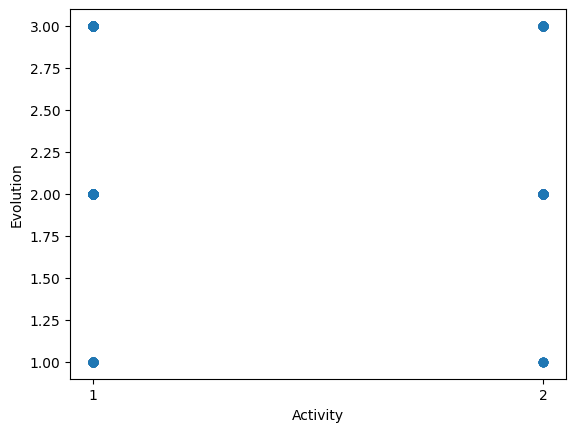

In [154]:
#This needs to be a scatter
ActivityVsEvolution = pd.DataFrame({'x':df["activity"], 'y':df["evolution"]})

plt.scatter(ActivityVsEvolution['x'], ActivityVsEvolution['y'])
plt.xticks([1,2])
plt.xlabel("Activity")
plt.ylabel("Evolution")
plt.show()

# Z Class vs C, M, and X

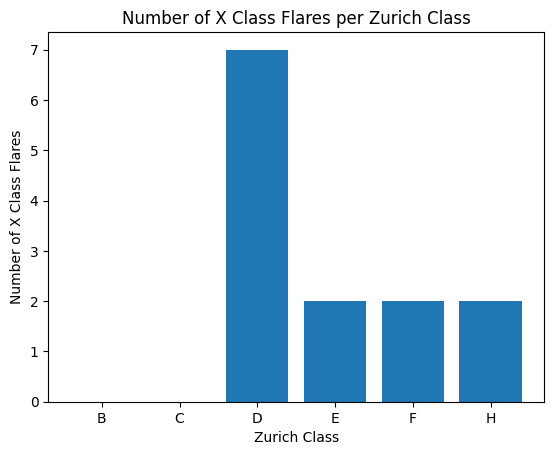

In [60]:
z_v_x_class_counts = df.groupby("zurich_class")["x_class_flares"].sum()
plt.bar(z_v_x_class_counts.index, z_v_x_class_counts.values)
plt.title("Number of X Class Flares per Zurich Class")
plt.xlabel("Zurich Class")
plt.ylabel("Number of X Class Flares")
plt.show()

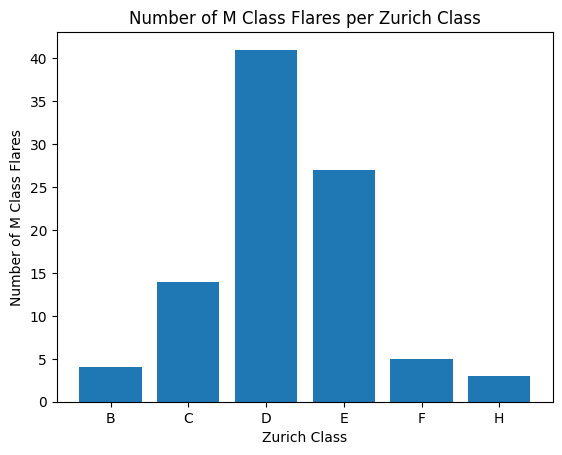

In [61]:
z_v_m_class_counts = df.groupby("zurich_class")["m_class_flares"].sum()
plt.bar(z_v_m_class_counts.index, z_v_m_class_counts.values)
plt.title("Number of M Class Flares per Zurich Class")
plt.xlabel("Zurich Class")
plt.ylabel("Number of M Class Flares")
plt.show()

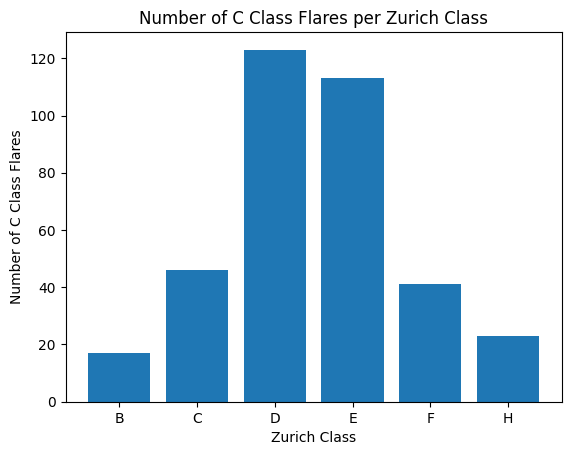

In [62]:
z_v_c_class_counts = df.groupby("zurich_class")["c_class_flares"].sum()
plt.bar(z_v_c_class_counts.index, z_v_c_class_counts.values)
plt.title("Number of C Class Flares per Zurich Class")
plt.xlabel("Zurich Class")
plt.ylabel("Number of C Class Flares")
plt.show()

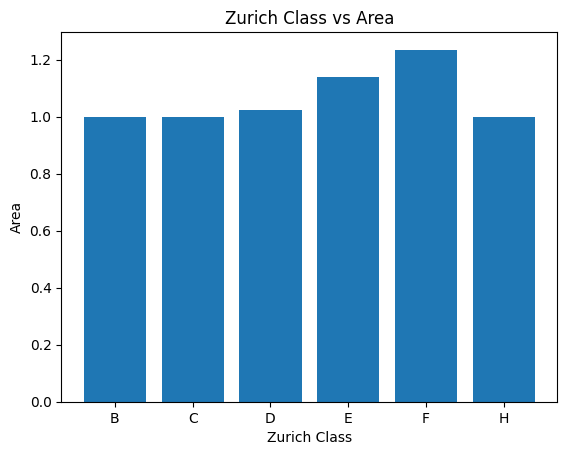

In [63]:
#categorical and numerical... needs to be a bar graph

zc_v_area_counts = df.groupby("zurich_class")["area"].mean()
plt.bar(zc_v_area_counts.index, zc_v_area_counts.values)

plt.title("Zurich Class vs Area")
plt.xlabel("Zurich Class")
plt.ylabel("Area")
plt.show()

The D class flares have what seem to be the most flares overall. I'm going to make a graph of how many of each they all have.

In [64]:
df_flares_only = df[["zurich_class", "c_class_flares", "m_class_flares", "x_class_flares"]]

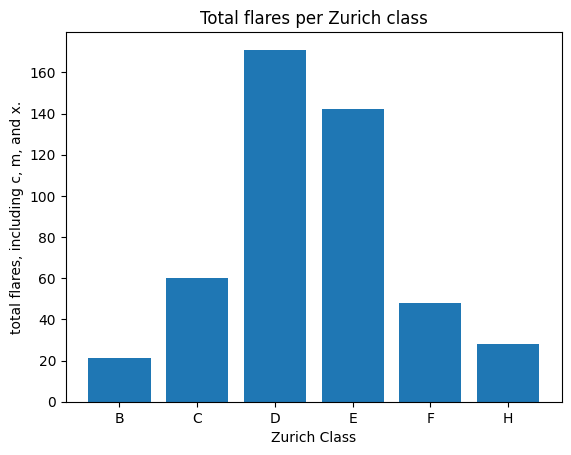

In [65]:
# I can't get this one to work

total = df_total_flares.groupby("zurich_class")["total_flares"].sum()

plt.bar(total.index, total.values)

plt.title("Total flares per Zurich class")
plt.xlabel("Zurich Class")
plt.ylabel("total flares, including c, m, and x.")
plt.show()

# Z Class Vs Historic Complexities

The majority of historic complexity occured when it was an F class sunspot. There were the least amount of f class flares, so this data stands out.

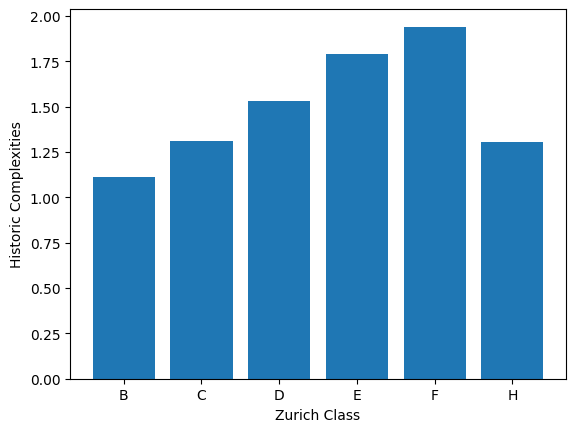

In [66]:
z_v_historic_complexities = df.groupby("zurich_class")["historically_complex"].mean()
plt.bar(z_v_historic_complexities.index, z_v_historic_complexities.values)

plt.xlabel("Zurich Class")
plt.ylabel("Historic Complexities")
plt.show()

# Different Variable Comparisons

John said to make a research question along the lines of 'which variable affects the flares the most'

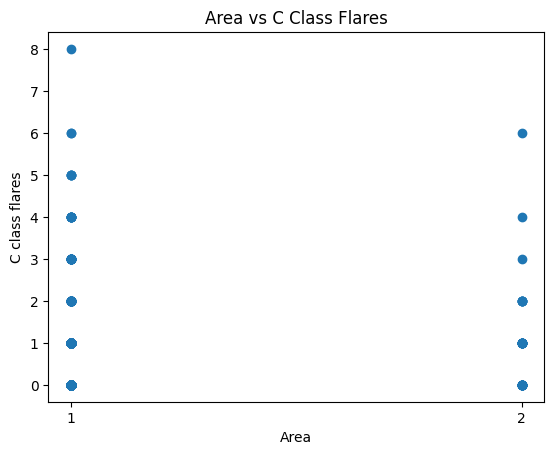

In [97]:
plt.scatter(df["area"], df["c_class_flares"])
plt.title("Area vs C Class Flares")
plt.xlabel("Area")
plt.ylabel("C class flares")
plt.xticks([1,2])

plt.show()

X class vs evolution.

Evolution   (1 = decay, 2 = no growth, 3 = growth)

Previous 24 hour flare activity code    (1 = nothing as big as an M1, 2 = one M1, 3 = more activity than one M1)

the only time there were 2 x-class flares were when the sunspot had growth.

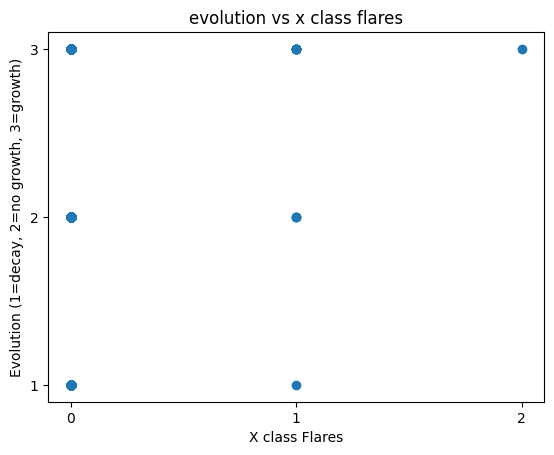

In [138]:
plt.scatter (df["x_class_flares"], df["evolution"])

plt.title("evolution vs x class flares")
plt.xlabel("X class Flares")
plt.ylabel("Evolution (1=decay, 2=no growth, 3=growth)")
plt.xticks([0,1,2])
plt.yticks([1,2,3])

plt.show()

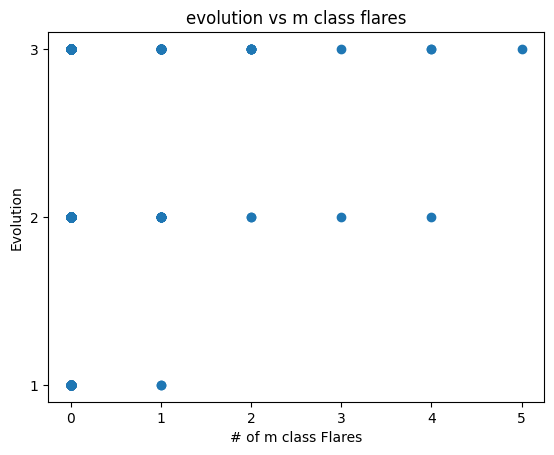

In [100]:
plt.scatter (df["m_class_flares"], df["evolution"])

plt.title("evolution vs m class flares")
plt.xlabel("# of m class Flares")
plt.ylabel("Evolution")
plt.yticks([1,2,3])

plt.show()

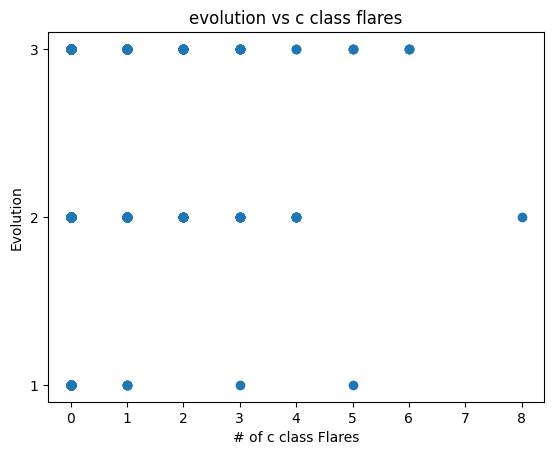

In [101]:
plt.scatter (df["c_class_flares"], df["evolution"])

plt.title("evolution vs c class flares")
plt.xlabel("# of c class Flares")
plt.ylabel("Evolution")
plt.yticks([1,2,3])

plt.show()

In [71]:
df[df["c_class_flares"]==8]

,zurich_class,largest_spot_size,spot_distribution,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares,total_flares
366,E,A,I,2,2,1,1,2,1,1,8,0,0,8


x class flares vs area of the largest spot

Area of the largest spot                (1 = <=5, 2 = >5)

when the area of the largest spot was less than or equal to 5, there were 2 x class flares.

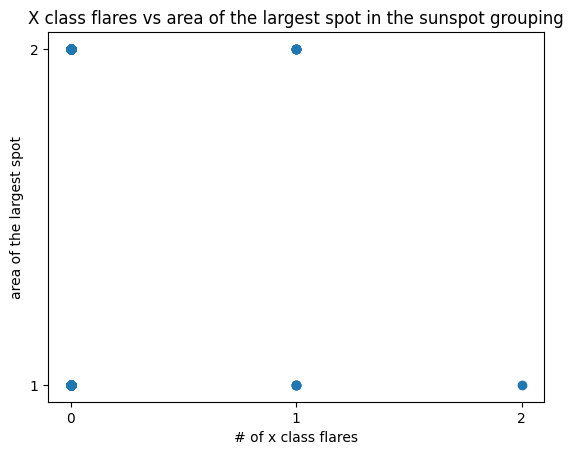

In [155]:
plt.scatter(df["x_class_flares"], df["area_largest_spot"])
plt.title("X class flares vs area of the largest spot in the sunspot grouping")
plt.xlabel("# of x class flares")
plt.ylabel("area of the largest spot")
plt.yticks([1,2])
plt.xticks([0,1,2])

plt.show()

# Complexity

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   zurich_class              1389 non-null   object
 1   largest_spot_size         1389 non-null   object
 2   spot_distribution         1389 non-null   object
 3   activity                  1389 non-null   int64 
 4   evolution                 1389 non-null   int64 
 5   prev_24hr_flare_activity  1389 non-null   int64 
 6   historically_complex      1389 non-null   int64 
 7   became_complex_this_pass  1389 non-null   int64 
 8   area                      1389 non-null   int64 
 9   area_largest_spot         1389 non-null   int64 
 10  c_class_flares            1389 non-null   int64 
 11  m_class_flares            1389 non-null   int64 
 12  x_class_flares            1389 non-null   int64 
dtypes: int64(10), object(3)
memory usage: 141.2+ KB


In [157]:
#going to try to make a heat map
#plt.imshow(data=df["c_class_flares"], cmap="viridis")
#plt.show()
# That wasn't working so now trying to make the points bigger the more they have
#sns.scatterplot(data=df['historically_complex'], x=None, y=None, hue=None, size=None, style=None, palette=None, hue_order=None, hue_norm=None, sizes=None, size_order=None, size_norm=None, markers=True, style_order=None, legend='auto', ax=None)

Historic complexity

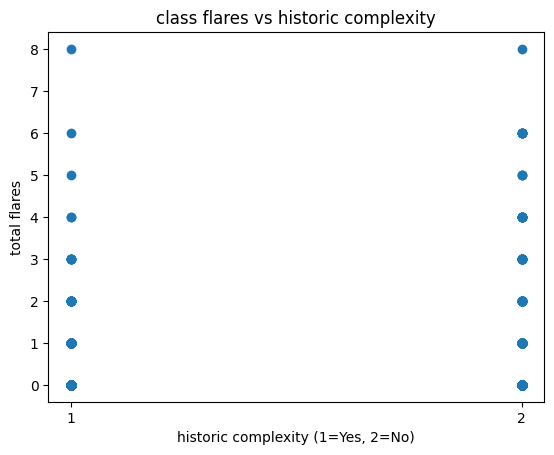

In [145]:
plt.scatter(df["historically_complex"], total_flares)
plt.title("class flares vs historic complexity")
plt.xticks([1,2])
plt.ylabel("total flares")
plt.xlabel("historic complexity (1=Yes, 2=No)")
plt.show()

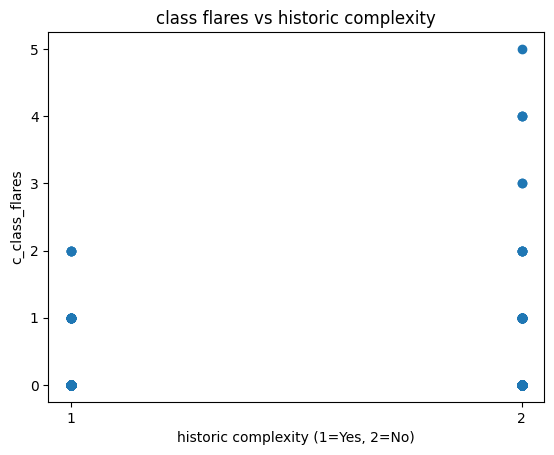

In [92]:
plt.scatter(df["historically_complex"], df["m_class_flares"])
plt.title("class flares vs historic complexity")
plt.ylabel("c_class_flares")
plt.xlabel("historic complexity (1=Yes, 2=No)")
plt.xticks([1,2])

plt.show()

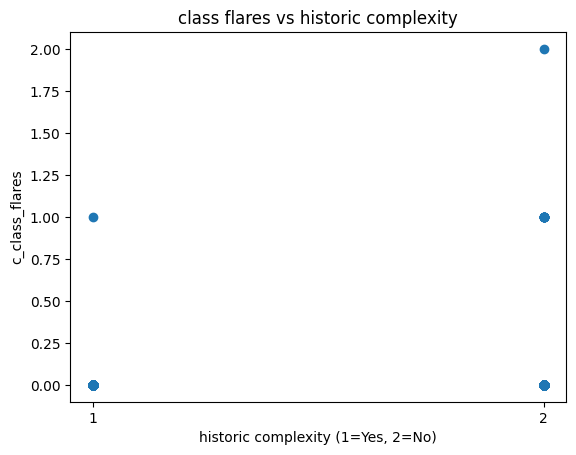

In [93]:
plt.scatter(df["historically_complex"], df["x_class_flares"])
plt.title("class flares vs historic complexity")
plt.ylabel("c_class_flares")
plt.xlabel("historic complexity (1=Yes, 2=No)")
plt.xticks([1,2])

plt.show()

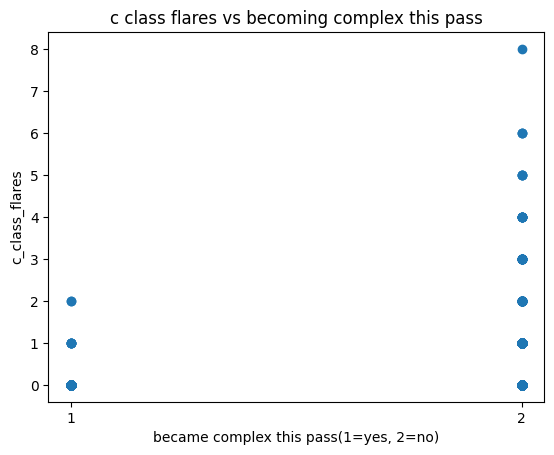

In [94]:
plt.scatter(df["became_complex_this_pass"], df["c_class_flares"])
plt.title("c class flares vs becoming complex this pass")
plt.ylabel("c_class_flares")
plt.xlabel("became complex this pass(1=yes, 2=no)")
plt.xticks([1,2])


plt.show()
#I’m interested in a decision tree. Do you have any resources that could help me learn how to make one?

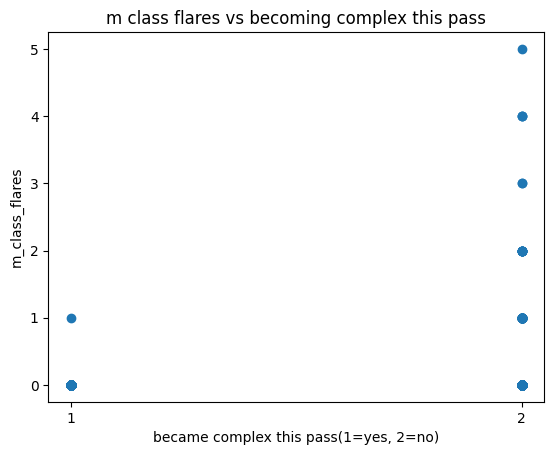

In [95]:
plt.scatter(df["became_complex_this_pass"], df["m_class_flares"])
plt.title("m class flares vs becoming complex this pass")
plt.ylabel("m_class_flares")
plt.xlabel("became complex this pass(1=yes, 2=no)")
plt.xticks([1,2])


plt.show()

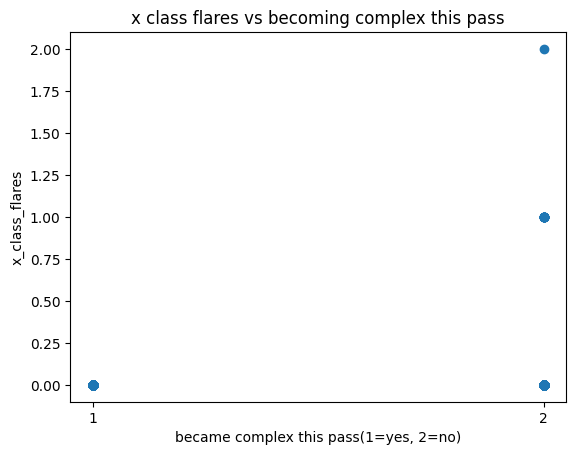

In [96]:
plt.scatter(df["became_complex_this_pass"], df["x_class_flares"])
plt.title("x class flares vs becoming complex this pass")
plt.ylabel("x_class_flares")
plt.xlabel("became complex this pass(1=yes, 2=no)")
plt.xticks([1,2])

plt.show()

# New Data Frame

In [159]:
dfx = df[df["x_class_flares"] > 0]
dfx

,zurich_class,largest_spot_size,spot_distribution,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares
30,D,A,O,1,3,1,1,2,1,2,1,0,1
62,D,K,C,2,3,3,2,2,1,2,1,2,1
75,D,K,I,1,3,1,2,2,1,2,0,2,1
106,H,S,X,1,1,1,2,2,1,2,0,0,1
257,D,K,C,1,3,1,2,2,1,2,0,1,1
259,H,A,X,1,3,1,2,2,1,2,0,1,1
310,D,K,C,2,2,3,2,2,2,2,1,0,1
546,F,A,I,2,2,1,2,2,1,1,1,0,1
1273,F,K,C,1,2,1,2,2,2,1,0,1,1
1283,D,K,C,2,3,1,2,2,2,1,1,3,2


In [160]:
total_flares = df["c_class_flares"] + df["m_class_flares"] + df["x_class_flares"]

In [161]:
df_total_flares = df
df_total_flares['total_flares'] = total_flares
df_total_flares

,zurich_class,largest_spot_size,spot_distribution,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares,total_flares
0,C,S,O,1,2,1,1,2,1,2,0,0,0,0
1,D,S,O,1,3,1,1,2,1,2,0,0,0,0
2,C,S,O,1,3,1,1,2,1,1,0,0,0,0
3,D,S,O,1,3,1,1,2,1,2,0,0,0,0
4,D,A,O,1,3,1,1,2,1,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,H,S,X,1,2,1,1,1,1,1,0,0,0,0
1385,H,S,X,2,2,1,1,2,1,1,0,0,0,0
1386,C,S,O,1,2,1,2,2,1,1,0,0,0,0
1387,H,R,X,1,2,1,1,2,1,1,0,0,0,0


In [162]:
df

,zurich_class,largest_spot_size,spot_distribution,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares,total_flares
0,C,S,O,1,2,1,1,2,1,2,0,0,0,0
1,D,S,O,1,3,1,1,2,1,2,0,0,0,0
2,C,S,O,1,3,1,1,2,1,1,0,0,0,0
3,D,S,O,1,3,1,1,2,1,2,0,0,0,0
4,D,A,O,1,3,1,1,2,1,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,H,S,X,1,2,1,1,1,1,1,0,0,0,0
1385,H,S,X,2,2,1,1,2,1,1,0,0,0,0
1386,C,S,O,1,2,1,2,2,1,1,0,0,0,0
1387,H,R,X,1,2,1,1,2,1,1,0,0,0,0


Notes from Mentor Meeting today:

Dr. Wooten said to maybe make a heat map because it's hard to tell how many points are in one place.

cite data

Include C in the research question

make data more polished: only do possible values on x and y axes, etc

think about the real world when you're making your project

any graph should tell most of the story... audience should mostly get it, then you explain it, then they should easily get it.